In [8]:
from model.model_v1 import actor_v1, critic_v1
from scripts_env_v_4.variable_leverage_env_4 import agentDLVEnvV4
from scripts_env_v_4.utils import plot_metrics_v4
import torch
import torch.nn as nn
import torch.multiprocessing as mp
import torch.nn.functional as F
from tqdm import trange, tqdm
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

In [9]:
def naiveAgent(obs, min_cr=1.2, eps=1e-9):
    leverage = obs[0]
    cr = 1/obs[1]

    if cr <= min_cr + 0.03:
        return 1
    if leverage >= 0.95 or leverage <= 0.05:
        return 1
    else:
        return 0

def generateSingleEpisode(seed: int, env_mech: agentDLVEnvV4, env_bot: agentDLVEnvV4, model: actor_v1, width = None, middle = None):
    if (width is None) or (middle is None):
        obs1, _ = env_mech.reset(seed = seed)
        obs2, _ = env_bot.reset(seed = seed)
    else:
        obs1, _ = env_mech.reset(seed = seed, top_leverage = middle + 0.5*width, bottom_leverage = middle - 0.5*width)
        obs2, _ = env_bot.reset(seed = seed, top_leverage = middle + 0.5*width, bottom_leverage = middle - 0.5*width)

    done = False

    while not done:
        action = naiveAgent(obs1)
        obs1, reward, terminated, truncated, info = env_mech.step(action)
        done = terminated or truncated
        if done:
            mech_integral_loss = info['integral loss']
            mech_steps = info['steps']
            mech_quantile = info['quantile']
            mech_loss_rate = info['loss_rate']

    ep_obs = []
    ep_reward = []
    ep_action = []

    done = False

    with torch.no_grad():
        hidden = model.init_hidden()

        while not done:
            ep_obs.append(obs2)

            action, hidden, _, _, _ = model.forward_single(obs2, hidden)
            obs2, reward, terminated, truncated, info = env_bot.step(action.item())
            done = terminated or truncated

            ep_reward.append(reward)
            ep_action.append(action.item())

            if done:
                bot_integral_loss = info['integral loss']
                bot_steps = info['steps']
                bot_quantile = info['quantile']
                bot_loss_rate = info['loss_rate']
    
    return {
        'per_step_rewards': ep_reward,
        'global_scalar_reward': mech_loss_rate - bot_loss_rate,
        'actions': ep_action,
        'obs': ep_obs,
        'steps': bot_steps,
        'bot_quantile': bot_quantile,
        'mech_integral_loss': mech_integral_loss,
        'bot_integral_loss': bot_integral_loss
    }

def worker_process(
        worker_id, 
        env_configs, 
        reward_configs, 
        stable_token_price, 
        nav,
        volatile_token_price,
        vol_part,
        shared_model, 
        seed, 
        width, 
        middle, 
        conn
    ):
    env_mech = agentDLVEnvV4(
        stable_token_price,
        nav,
        volatile_token_price,
        vol_part,
        top_leverage = middle + 0.5*width,
        bottom_leverage = middle - 0.5*width,
        seed = int(seed),
        is_training = True,
        is_mixed = env_configs['is_mixed'],
        is_reversed = env_configs['is_reversed'],
        is_syntetic = env_configs['is_synthetic'],
        show_setup = env_configs['show_setup'],
        primordial_action_penalty = reward_configs['primordial_action_penalty'],
        penalty_damping = reward_configs['penalty_damping'],
        idle_reward = reward_configs['idle_reward'],
        optimal_rebalancing_reward = reward_configs['optimal_rebalancing_reward'],
        extravagance_penalty = reward_configs['extravagance_penalty'],
        echo_penalty_damping = reward_configs['echo_penalty_damping'],
        positive_consequence_reward = reward_configs['positive_consequence_reward'],
        negative_consequence_penalty = reward_configs['negative_consequence_penalty']
    )
    env_bot = agentDLVEnvV4(
        stable_token_price,
        nav,
        volatile_token_price,
        vol_part,
        top_leverage = middle + 0.5*width,
        bottom_leverage = middle - 0.5*width,
        seed = int(seed),
        is_training = True,
        is_mixed = env_configs['is_mixed'],
        is_reversed = env_configs['is_reversed'],
        is_syntetic = env_configs['is_synthetic'],
        show_setup = env_configs['show_setup'],
        primordial_action_penalty = reward_configs['primordial_action_penalty'],
        penalty_damping = reward_configs['penalty_damping'],
        idle_reward = reward_configs['idle_reward'],
        optimal_rebalancing_reward = reward_configs['optimal_rebalancing_reward'],
        extravagance_penalty = reward_configs['extravagance_penalty'],
        echo_penalty_damping = reward_configs['echo_penalty_damping'],
        positive_consequence_reward = reward_configs['positive_consequence_reward'],
        negative_consequence_penalty = reward_configs['negative_consequence_penalty']
    )

    with torch.no_grad():
        ep = generateSingleEpisode(
            seed=seed,
            env_mech=env_mech,
            env_bot=env_bot,
            model=shared_model,
            width=width,
            middle=middle,
        )

    conn.send(ep)
    conn.close()

In [10]:
class bot_trainer:
    def __init__(
        self, 
        volatile_token_price,
        stable_token_price,
        nav,
        vol_part,
        timestamps,
        env_configs,
        reward_configs,
        width,
        middle_leverage = 2,
        device = 'cpu'
    ):
        self.volatile_token_price = volatile_token_price.copy()
        self.stable_token_price = stable_token_price.copy()
        self.nav = nav.copy()
        self.vol_part = vol_part.copy()
        self.timestamps = timestamps.copy()
        self.env_configs = env_configs
        self.reward_configs = reward_configs
        self.device = device
        self.n_envs = len(env_configs)
        self.middle_leverage = middle_leverage
        self.width = width

        self.actor = actor_v1(device = device)
        self.actor.share_memory() # Move the model’s parameter tensors into shared OS memory so that other processes can read and use the same parameters without copying.
        self.critic = critic_v1(device = device)
        self.actor_state = self.actor.state_dict()
        self.critic_state = self.critic.state_dict()

        self.rng = np.random.default_rng()

        self.envs_mech = []
        for i in range(self.n_envs):
            env = agentDLVEnvV4(
                nect_honey_price = self.stable_token_price,
                nav_in_honey = self.nav,
                vol_token_honey_price = self.volatile_token_price,
                vol_part = self.vol_part,
                top_leverage = self.middle_leverage + 0.5*self.width,
                bottom_leverage = self.middle_leverage - 0.5*self.width,
                seed = int(self.rng.integers(0, 1e6)),
                is_training = True,
                is_mixed = self.env_configs[i]['is_mixed'],
                is_reversed = self.env_configs[i]['is_reversed'],
                is_syntetic = self.env_configs[i]['is_synthetic'],
                show_setup = self.env_configs[i]['show_setup'],
                primordial_action_penalty = self.reward_configs['primordial_action_penalty'],
                penalty_damping = self.reward_configs['penalty_damping'],
                idle_reward = self.reward_configs['idle_reward'],
                optimal_rebalancing_reward = self.reward_configs['optimal_rebalancing_reward'],
                extravagance_penalty = self.reward_configs['extravagance_penalty'],
                echo_penalty_damping = self.reward_configs['echo_penalty_damping'],
                positive_consequence_reward = self.reward_configs['positive_consequence_reward'],
                negative_consequence_penalty = self.reward_configs['negative_consequence_penalty']
            )

            self.envs_mech.append(env)

        self.envs_bot = []
        for i in range(self.n_envs):
            env = agentDLVEnvV4(
                self.stable_token_price,
                self.nav,
                self.volatile_token_price,
                self.vol_part,
                top_leverage = self.middle_leverage + 0.5*self.width,
                bottom_leverage = self.middle_leverage - 0.5*self.width,
                seed = int(self.envs_mech[i].seed),
                is_training = True,
                is_mixed = self.env_configs[i]['is_mixed'],
                is_reversed = self.env_configs[i]['is_reversed'],
                is_syntetic = self.env_configs[i]['is_synthetic'],
                show_setup = self.env_configs[i]['show_setup'],
                primordial_action_penalty = self.reward_configs['primordial_action_penalty'],
                penalty_damping = self.reward_configs['penalty_damping'],
                idle_reward = self.reward_configs['idle_reward'],
                optimal_rebalancing_reward = self.reward_configs['optimal_rebalancing_reward'],
                extravagance_penalty = self.reward_configs['extravagance_penalty'],
                echo_penalty_damping = self.reward_configs['echo_penalty_damping'],
                positive_consequence_reward = self.reward_configs['positive_consequence_reward'],
                negative_consequence_penalty = self.reward_configs['negative_consequence_penalty']
            )

            self.envs_bot.append(env)
    
    def generateSeveralEpisodesSequentialy(self, seed = None, width = None):
        rng = np.random.default_rng(seed = int(seed))

        returns = []
        for i in range(self.n_envs):
            local_seed = int(rng.integers(0, 1e6))
            local_bot_env = self.envs_bot[i]
            local_mech_env = self.envs_mech[i]
            local_middle = self.middle_leverage

            local_model = self.actor

            with torch.no_grad():
                ep_return = generateSingleEpisode(
                    seed = local_seed,
                    env_mech = local_mech_env,
                    env_bot = local_bot_env,
                    width = width,
                    model = local_model,
                    middle = local_middle
                )

            returns.append(ep_return)
        
        return returns
    
    def generateSeveralEpisodesParallel(self, seed = None, width = None):
        if width is None:
            width = self.width

        rng = np.random.default_rng(seed = int(seed))

        processes = []
        parent_conns = []
        results = []

        volatile_token_price = self.volatile_token_price
        stable_token_price = self.stable_token_price
        nav = self.nav
        vol_part = self.vol_part
        reward_configs = self.reward_configs
        
        for i in range(self.n_envs):
            local_seed = int(rng.integers(0, 1e6))
            local_middle = self.middle_leverage
            env_configs = self.env_configs[i]

            parent_conn, child_conn = mp.Pipe()
            p = mp.Process(
                target = worker_process,
                args = (
                    i,
                    env_configs,
                    reward_configs,
                    stable_token_price,
                    nav,
                    volatile_token_price,
                    vol_part,
                    self.actor,
                    local_seed,
                    width,
                    local_middle,
                    child_conn
                )
            )

            p.start()
            processes.append(p)
            parent_conns.append(parent_conn)
        
        for conn in parent_conns:
            results.append(conn.recv())
            conn.close()
        
        for p in processes:
            p.join()

        return results
    
    def model_train(
        self,
        n_episodes,
        n_repeats = 1,
        lr = 1e-4,
        ent_coef = 0.01,
        ent_alt_coef = 0.01,
        critic_coef = 0.2
    ):
        def resolve_schedule(x, frac):
            if callable(x):
                return x(frac)
            else:
                return x
            
        self.actor.train()
        self.critic.train()

        optimizer_actor = torch.optim.Adam(self.actor.parameters(), lr = resolve_schedule(lr, 0))
        optimizer_critic = torch.optim.Adam(self.critic.parameters(), lr = resolve_schedule(lr, 0))

        rng = np.random.default_rng()

        for episode in trange(n_episodes, desc="Training"):
            frac = episode/(n_episodes - 1) if n_episodes > 1 else 1

            if episode % n_repeats == 0:
                seed = int(rng.integers(0, 1e6))
            
            ent_coef_t = resolve_schedule(ent_coef, frac)
            lr_t = resolve_schedule(lr, frac)
            critic_coef_t = resolve_schedule(critic_coef, frac)
            ent_alt_coef_t = resolve_schedule(ent_alt_coef, frac)

            for g in optimizer_actor.param_groups:
                g['lr'] = lr_t

            for g in optimizer_critic.param_groups:
                g['lr'] = lr_t

            ep_data_full = self.generateSeveralEpisodesSequentialy(seed = seed)

            optimizer_actor.zero_grad()
            optimizer_critic.zero_grad()

            reward = []
            action = []
            obs = []

            for i, ep in enumerate(ep_data_full):
                batch_reward_list = ep['rewards']
                batch_obs_list = ep['obs']
                batch_action_list = ep['actions']

                reward.append(batch_reward_list)
                action.append(batch_action_list)
                obs.append(batch_obs_list)
            
            reward_t = torch.tensor(reward, dtype=torch.float32, device=self.device)
            action_t = torch.tensor(action, dtype=torch.float32, device=self.device)
            obs_t = torch.tensor(obs, dtype=torch.float32, device=self.device)

            hiddents_actor = self.actor.init_hidden(batch_size = self.n_envs)
            hiddents_critic = self.critic.init_hidden(batch_size = self.n_envs)

            _, _, log_probs_t, entropies_t, entropies_alt_t = self.actor.forward_batch(
                obs_t, 
                hiddents_actor, 
                with_alt_entropy = True, 
                forced_action = action_t
            )

            values_t, _ = self.critic.forward_batch(
                obs_t,
                hiddents_critic
            )

            advantages = reward_t - values_t.detach()

            policy_loss = -(log_probs_t * advantages.detach()).mean()
            entropy_loss = -ent_coef_t * entropies_t.mean()
            value_loss = critic_coef_t*F.mse_loss(values_t, reward_t)
            entropy_loss_alt = -ent_alt_coef_t * entropies_alt_t.mean()
            total_loss = policy_loss + entropy_loss + value_loss + entropy_loss_alt

            total_loss = total_loss/self.n_envs
            total_loss.backward()

            clip_actor = torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 1)
            clip_critic = torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 1)
            optimizer_actor.step()
            optimizer_critic.step()
            self.actor_state = self.actor.state_dict()
            self.critic_state = self.critic.state_dict()

    def test_env(self, seed = None, env = None, is_training = False):
        if env is None:
            env = self.envs_mech[0]
        
        original_is_training = env.is_training
        print(original_is_training)
        env.is_training = is_training

        time_init = tm.time()

        done = False
        obs, _ = env.reset(seed = seed)

        while not done:
            action = naiveAgent(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        time_done = tm.time()
        print("Env episode time", int((time_done - time_init)*10000)/10000)
        if is_training:
            print("Loss rate", info['loss_rate'])
            print("Integral loss", info['integral loss'])
            print("Leverage deviation quantile", info['quantile'])
            print("Leverage mean", info['mean'])

            time = np.arange(len(info['losses']))

            plt.figure(figsize=(12, 5))
            plt.plot(time, info['leverage'], color = 'blue', label = 'mech agent leverage')
            plt.legend()
            plt.xlabel('step')
            plt.ylabel('leverage')
            plt.grid(True)
            plt.show()

            plt.figure(figsize=(12, 5))
            plt.plot(time, info['losses'], color = 'blue', label = 'mech agent loss')
            plt.plot(time, time*info['loss_rate']/1e7, linestyle='--', color = 'blue')
            plt.legend()
            plt.xlabel('step')
            plt.ylabel('loss')
            plt.grid(True)
            plt.show()
        else:
            history = info['episode_history']
            history_metrics = info['episode_metrics']
            economic_metrics = info['episode_economics']
            t_l = info['top leverage']
            b_l = info['bottom leverage']
            not_doing = info.get('0 action')  
            action_1 = info.get('0.5 rebalancing') 
            action_2 = info.get('0.75 rebalancing') 
            action_3 = info.get('0.25 rebalancing') 

            print('doing nothing', not_doing*100, '%')
            print('action 1', action_1*100, '%')
            print('action 2', action_2*100, '%')
            print('action 3', action_3*100, '%')

            print(np.quantile(history_metrics['equilibrium distance slope'], 0.98))
            print(3.07768/np.quantile(history_metrics['equilibrium distance slope'], 0.98))
            print(np.quantile(history_metrics['equilibrium distance slope'], 0.98)/1.09861)

            plot_metrics_v4(history_metrics)
            

In [11]:
df = pd.read_csv('wbtc_train_data_expanded.csv')

timestamps = df['timestamp'].values
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values

nav = nav[::4]
nect_price = nect_price[::4]
vol_token_price = vol_token_price[::4]
volatile_part = volatile_part[::4]
timestamps = timestamps[::4]

In [12]:
env_configs = [{
    'is_synthetic': True,
    'is_mixed': False,
    'is_reversed': False,
    'show_setup': False
}]

reward_configs = {
    'primordial_action_penalty': 0.4,
    'penalty_damping': 0.99,
    'idle_reward': 0.05,
    'optimal_rebalancing_reward': 0.1,
    'extravagance_penalty': 0.25,
    'echo_penalty_scale': 1,
    'echo_penalty_damping': 0.99,
    'positive_consequence_reward': 0.12,
    'negative_consequence_penalty': 0.2
}

In [13]:
trainer = bot_trainer(
    vol_token_price,
    nect_price,
    nav,
    volatile_part,
    timestamps,
    env_configs,
    reward_configs,
    width = 0.4,
    middle_leverage = 2
)

True
Env episode time 0.6899
doing nothing 99.83392152792194 %
action 1 0.1660784720780569 %
action 2 0.0 %
action 3 0.0 %
0.8336770370185346
3.69169338165611
0.7588471222895609


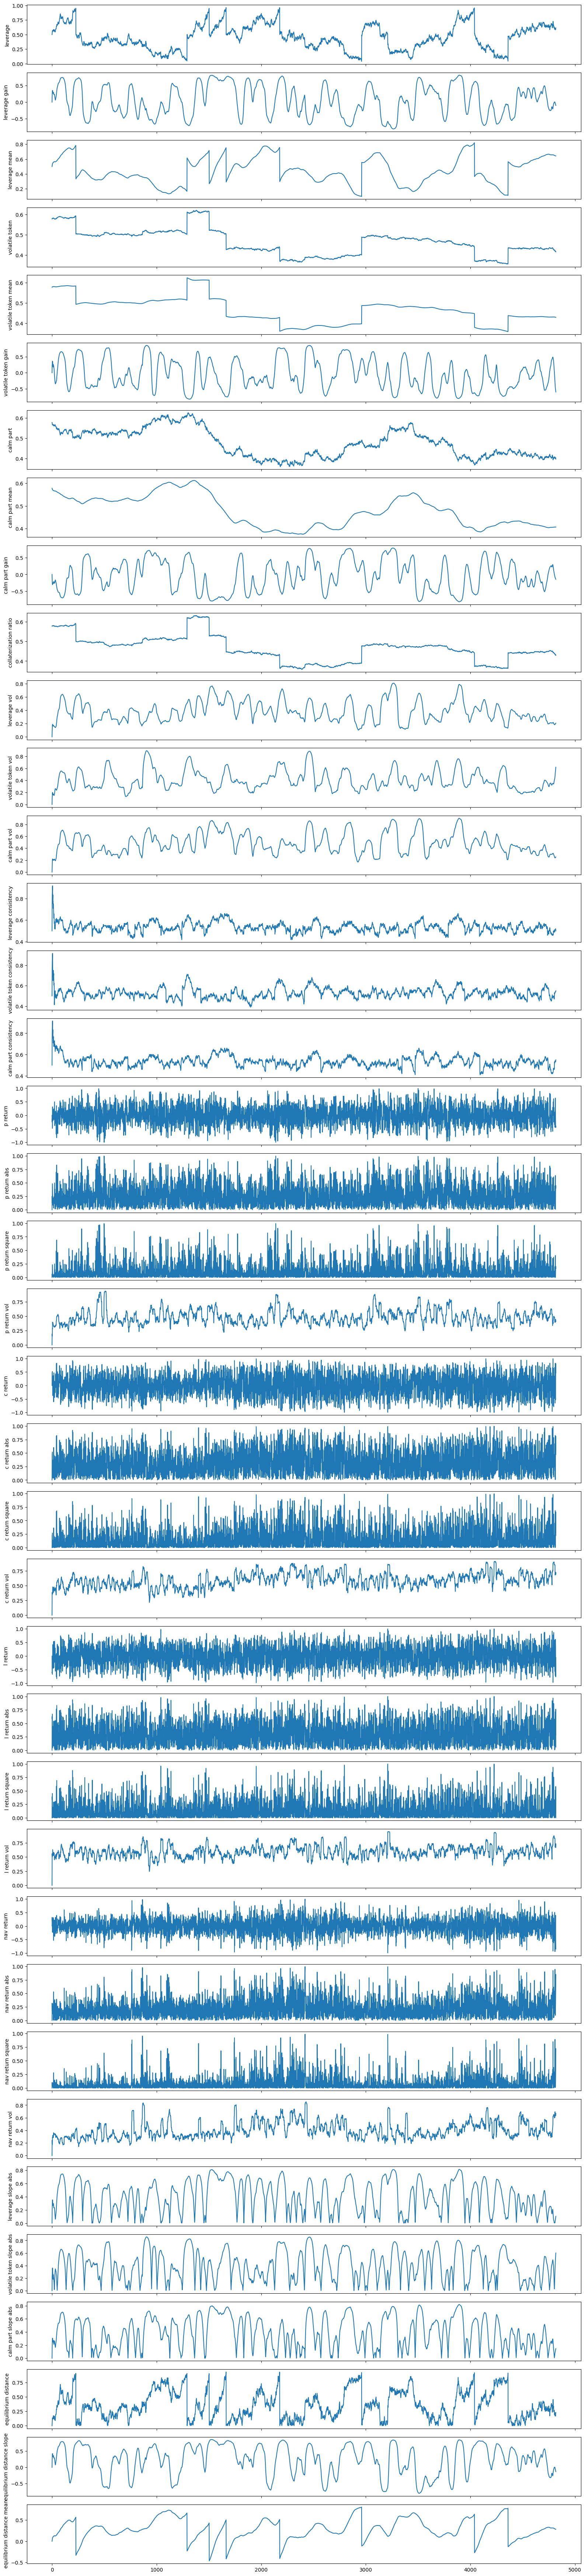

In [14]:
trainer.test_env(is_training = False)